In [11]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [17]:
canvas = np.ones((100, 100, 3), dtype='uint8') * 255

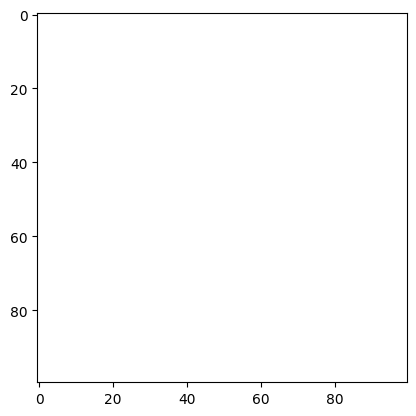

In [13]:
plt.imshow(canvas)

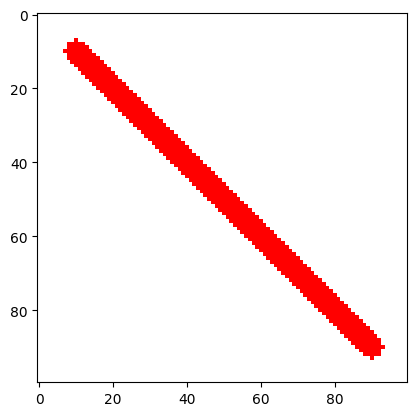

In [14]:
cv2.line(canvas, (10, 10), (90, 90), (255, 0, 0), thickness=5)
plt.imshow(canvas)

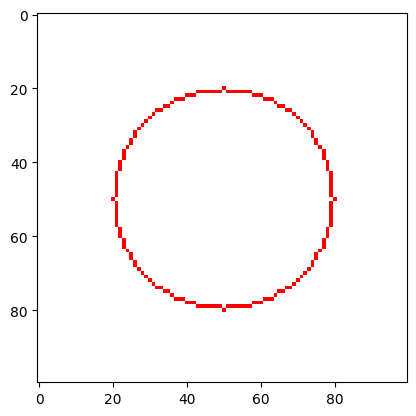

In [18]:
cv2.circle(canvas, (50, 50), 30, (255, 0, 0), 1)
plt.imshow(canvas)

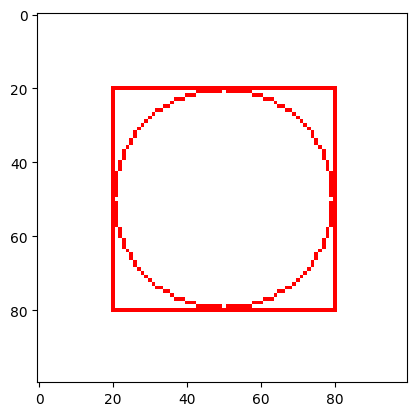

In [20]:
cv2.rectangle(canvas, (20, 20), (80, 80), (255, 0, 0), 1)
plt.imshow(canvas)

In [21]:
cv2.addText(canvas, 'Hello', (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
plt.imshow(canvas)

TypeError: Can't convert object to 'str' for 'nameFont'

In [22]:
import cv2
import numpy as np

# Create white canvas
canvas = np.ones((600, 900, 3), dtype="uint8") * 255

# Drawing state variables
drawing = False
mode = "free"   # "free" or "rect"
color = (0, 0, 255)  # Default Red
thickness = 3
start_x, start_y = -1, -1


def mouse_events(event, x, y, flags, param):
    global drawing, start_x, start_y, canvas

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        start_x, start_y = x, y

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            if mode == "free":
                cv2.circle(canvas, (x, y), thickness, color, -1)
            elif mode == "rect":
                temp = canvas.copy()
                cv2.rectangle(temp, (start_x, start_y), (x, y), color, thickness)
                cv2.imshow("OpenCV Draw App", temp)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        if mode == "rect":
            cv2.rectangle(canvas, (start_x, start_y), (x, y), color, thickness)


cv2.namedWindow("OpenCV Draw App")
cv2.setMouseCallback("OpenCV Draw App", mouse_events)

print("""
======== OpenCV Drawing App ========

Press:
F  → Free draw mode
R  → Rectangle mode
1  → Red
2  → Green
3  → Blue
+  → Increase thickness
-  → Decrease thickness
C  → Clear canvas
S  → Save image
ESC → Exit

====================================
""")

while True:
    cv2.imshow("OpenCV Draw App", canvas)
    key = cv2.waitKey(1) & 0xFF

    # Mode switching
    if key == ord('f'):
        mode = "free"
    elif key == ord('r'):
        mode = "rect"

    # Color switching
    elif key == ord('1'):
        color = (0, 0, 255)  # Red
    elif key == ord('2'):
        color = (0, 255, 0)  # Green
    elif key == ord('3'):
        color = (255, 0, 0)  # Blue

    # Thickness control
    elif key == ord('+'):
        thickness += 1
    elif key == ord('-'):
        thickness = max(1, thickness - 1)

    # Clear
    elif key == ord('c'):
        canvas[:] = 255

    # Save
    elif key == ord('s'):
        cv2.imwrite("my_drawing.png", canvas)
        print("Saved as my_drawing.png")

    # Exit
    elif key == 27:
        break

cv2.destroyAllWindows()


======== OpenCV Drawing App ========

Press:
F  → Free draw mode
R  → Rectangle mode
1  → Red
2  → Green
3  → Blue
+  → Increase thickness
-  → Decrease thickness
C  → Clear canvas
S  → Save image
ESC → Exit


